# Notebook with calculations useful for the bsd video
In particular nt_graph.json is created here as well as list of points copied over into the manim code

## Finding a nice curve to use

In [8]:
bound = 20
ABs = flatten([[(A,B) for B in srange(-bound,bound) if 4*A^3+27*B^2!= 0] for A in srange(-bound,bound)], max_level=1)
ABs.sort(key=lambda x : x[0]^2+x[1]^2)
ABs[:10]


[(-1, 0),
 (0, -1),
 (0, 1),
 (1, 0),
 (-1, -1),
 (-1, 1),
 (1, -1),
 (1, 1),
 (-2, 0),
 (0, -2)]

In [9]:
li2 = []
li0 = []
for A,B in ABs:
    E = EllipticCurve([A,B])
    try:
        r = E.rank(use_database=True)
    except:
        pass
    else:
        if r>1:
            X = E.integral_points()
            print(f"{A}, {B}, rank={r} has {len(X)} integral points: {X}")
            li2.append((A,B))
        if r==0 and A^2+B^2<100:
            if E.torsion_order() > 2:
                print(f"{A}, {B} has {E.torsion_order()} torsion points {E.torsion_points()}")
                li0.append((A,B))

-1, 0 has 4 torsion points [(0 : 1 : 0), (-1 : 0 : 1), (0 : 0 : 1), (1 : 0 : 1)]
0, 1 has 6 torsion points [(0 : 1 : 0), (-1 : 0 : 1), (0 : -1 : 1), (0 : 1 : 1), (2 : -3 : 1), (2 : 3 : 1)]
-2, 1 has 4 torsion points [(0 : 1 : 0), (0 : -1 : 1), (0 : 1 : 1), (1 : 0 : 1)]
1, 2 has 4 torsion points [(0 : 1 : 0), (-1 : 0 : 1), (1 : -2 : 1), (1 : 2 : 1)]
-4, 0 has 4 torsion points [(0 : 1 : 0), (-2 : 0 : 1), (0 : 0 : 1), (2 : 0 : 1)]
0, 4 has 3 torsion points [(0 : 1 : 0), (0 : -2 : 1), (0 : 2 : 1)]
4, 0 has 4 torsion points [(0 : 1 : 0), (0 : 0 : 1), (2 : -4 : 1), (2 : 4 : 1)]
-4, 1, rank=2 has 11 integral points: [(-2 : -1 : 1), (-1 : -2 : 1), (0 : -1 : 1), (2 : -1 : 1), (3 : -4 : 1), (4 : -7 : 1), (10 : -31 : 1), (12 : -41 : 1), (20 : -89 : 1), (114 : -1217 : 1), (1274 : -45473 : 1)]
-1, 4, rank=2 has 7 integral points: [(-1 : -2 : 1), (0 : -2 : 1), (1 : -2 : 1), (4 : -8 : 1), (15 : -58 : 1), (17 : -70 : 1), (4064 : -259078 : 1)]
4, -1, rank=2 has 3 integral points: [(1 : -2 : 1), (5 : -1

In [10]:
len(li0), len(li2)

(11, 206)

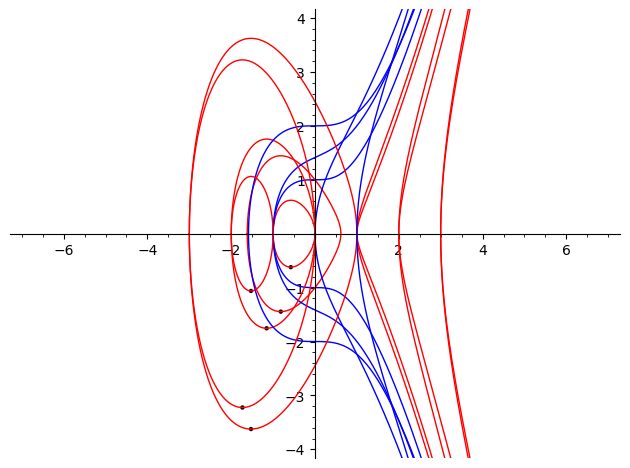

In [17]:
gr = Graphics()
for (A,B) in li0:
    co = "red" if A<0 else "blue"
    if A<0:
        x0 = sqrt(-A/3)
        ysq = x0^3+A*x0+B
        if ysq > 0:
            gr += point([x0,sqrt(ysq)],color="black")
        ysq = -x0^3-A*x0+B
        if ysq > 0:
            gr += point([-x0,-sqrt(ysq)], color="black")
    gr += plot(EllipticCurve([A,B]), xmin=-7, xmax=7, ymax=4, ymin=-4, color=co)
gr.show(xmin=-7, xmax=7, ymin=-4, ymax=4)
    

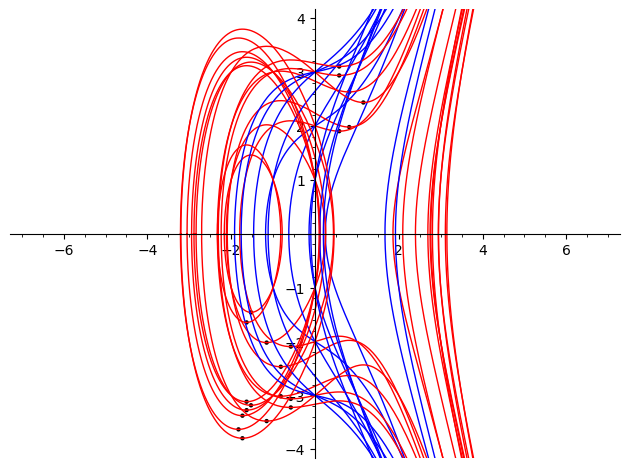

In [18]:
gr = Graphics()
for (A,B) in li2[:30]:
    co = "red" if A<0 else "blue"
    if A<0:
        x0 = sqrt(-A/3)
        ysq = x0^3+A*x0+B
        if ysq > 0:
            gr += point([x0,sqrt(ysq)],color="black")
        ysq = -x0^3-A*x0+B
        if ysq > 0:
            gr += point([-x0,-sqrt(ysq)], color="black")
    gr += plot(EllipticCurve([A,B]), xmin=-7, xmax=7, ymax=4, ymin=-4, color=co)
gr.show(xmin=-7, xmax=7, ymin=-4, ymax=4)

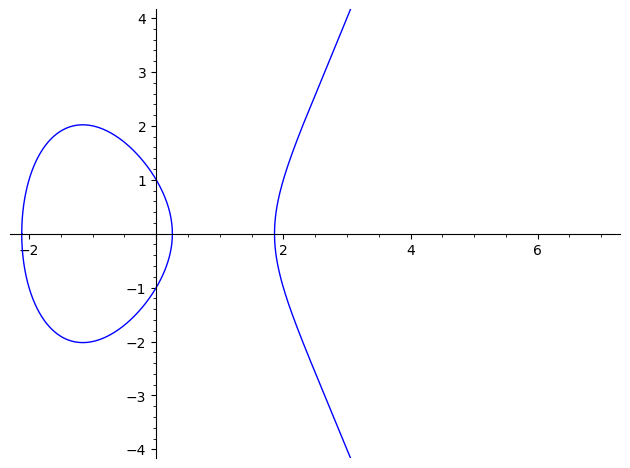

In [1]:
E = EllipticCurve([-4,1])
E.plot(ymin=-4, ymax=4, xmin=-7.11, xmax=7.11)

In [4]:
P,Q = E.gens()
P,Q, P.height(), Q.height()

((-1 : 2 : 1), (0 : 1 : 1), 0.945023010045590, 0.272741202034130)

In [5]:
E.height_pairing_matrix()

[ 0.945023010045590 -0.348250646165293]
[-0.348250646165293  0.272741202034130]

In [6]:
E.torsion_points()

[(0 : 1 : 0)]

In [7]:
pts_in_pic = []
for n in srange(-50, 50):
    for m in srange(-50,50):
        R = n*P+m*Q
        if R != 0:
            if R[0].abs() < 7.11 and R[1].abs() < 4:
                pts_in_pic.append((R, n, m))
pts_in_pic.sort(key=lambda R : R[0].height())
pts_in_pic[:50]

[((0 : -1 : 1), 0, -1),
 ((0 : 1 : 1), 0, 1),
 ((2 : -1 : 1), -1, -1),
 ((2 : 1 : 1), 1, 1),
 ((-2 : 1 : 1), -1, -2),
 ((-2 : -1 : 1), 1, 2),
 ((-1 : -2 : 1), -1, 0),
 ((-1 : 2 : 1), 1, 0),
 ((1/4 : 1/8 : 1), -2, -3),
 ((1/4 : -1/8 : 1), 2, 3),
 ((-7/4 : -13/8 : 1), 0, -3),
 ((-7/4 : 13/8 : 1), 0, 3),
 ((-2/9 : 37/27 : 1), -1, -4),
 ((-2/9 : -37/27 : 1), 1, 4),
 ((-8/9 : 53/27 : 1), -2, -1),
 ((-8/9 : -53/27 : 1), 2, 1),
 ((6/25 : -29/125 : 1), -1, 2),
 ((6/25 : 29/125 : 1), 1, -2),
 ((-16/25 : -227/125 : 1), -2, -5),
 ((-16/25 : 227/125 : 1), 2, 5),
 ((33/16 : 79/64 : 1), -2, 0),
 ((33/16 : -79/64 : 1), 2, 0),
 ((92/49 : 113/343 : 1), 0, -4),
 ((92/49 : -113/343 : 1), 0, 4),
 ((-90/49 : -503/343 : 1), -3, -4),
 ((-90/49 : 503/343 : 1), 3, 4),
 ((154/81 : 377/729 : 1), -3, -5),
 ((154/81 : -377/729 : 1), 3, 5),
 ((145/64 : -967/512 : 1), -2, -6),
 ((145/64 : 967/512 : 1), 2, 6),
 ((-10/169 : -2443/2197 : 1), -3, -2),
 ((-10/169 : 2443/2197 : 1), 3, 2),
 ((-248/121 : -1021/1331 : 1), -2

In [17]:
[P[0][1]*1. for P in pts_in_pic[80:100]]

[1.75680981859480,
 -1.75680981859480,
 0.0182926438953802,
 -0.0182926438953802,
 2.75121235764300,
 -2.75121235764300,
 -0.0931387950312056,
 0.0931387950312056,
 -1.50807620261466,
 1.50807620261466,
 0.0919194783867767,
 -0.0919194783867767,
 1.61245246550433,
 -1.61245246550433,
 -0.273872723212913,
 0.273872723212913,
 -0.147588216401666,
 0.147588216401666,
 1.79136441977637,
 -1.79136441977637]

In [19]:
pts_in_pic[100]

((6250080/33884041 : 102194916251/197239002661 : 1), -2, 5)

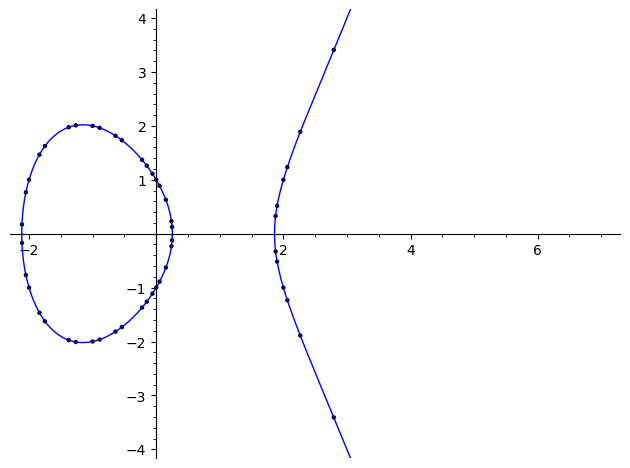

In [28]:
gr = E.plot(ymin=-4, ymax=4, xmin=-7.11, xmax=7.11)
for P in pts_in_pic[0:50]:
    gr += point([P[0],P[1]],color="black")
gr.show()

In [2]:
E.integral_points()

[(-2 : -1 : 1),
 (-1 : -2 : 1),
 (0 : -1 : 1),
 (2 : -1 : 1),
 (3 : -4 : 1),
 (4 : -7 : 1),
 (10 : -31 : 1),
 (12 : -41 : 1),
 (20 : -89 : 1),
 (114 : -1217 : 1),
 (1274 : -45473 : 1)]

## Rational points of small height on -4 +1

This is used in 3.1

In [4]:
E = EllipticCurve([-4,1])
P, Q = E.gens()

In [5]:
def intproj(S):
    if S == 0:
        return (0,1,0)
    z = S[1].denominator()
    e = z/S[0].denominator()
    y = S[1].numerator()
    x = e*S[0].numerator()  
    return (x,y,z)

In [6]:
def naive_height(S):
    (x,y,z) = intproj(S) 
    return max(abs(x), abs(y), abs(z))

In [7]:
pts = []
for n in srange(-50, 50):
    for m in srange(0,50):
        R = n*P+m*Q
        pts.append(R)
pts = [R if R[1]>= 0 else -R for R in pts]
pts = list(set(pts))  # remove duplicates

pts.sort(key=lambda R : (naive_height(R), R[2]) )  # sort by naive height and by z- coordinates if equal

for R in pts[:30]:
    (x,y,z) = intproj(R)
    print(fr'r"$({x}$, & $\pm {abs(y)}$, & ${z})$",')

r"$(0$, & $\pm 1$, & $0)$",
r"$(0$, & $\pm 1$, & $1)$",
r"$(-2$, & $\pm 1$, & $1)$",
r"$(-1$, & $\pm 2$, & $1)$",
r"$(2$, & $\pm 1$, & $1)$",
r"$(3$, & $\pm 4$, & $1)$",
r"$(4$, & $\pm 7$, & $1)$",
r"$(2$, & $\pm 1$, & $8)$",
r"$(-14$, & $\pm 13$, & $8)$",
r"$(10$, & $\pm 31$, & $1)$",
r"$(-6$, & $\pm 37$, & $27)$",
r"$(12$, & $\pm 41$, & $1)$",
r"$(-24$, & $\pm 53$, & $27)$",
r"$(20$, & $\pm 89$, & $1)$",
r"$(30$, & $\pm 29$, & $125)$",
r"$(132$, & $\pm 79$, & $64)$",
r"$(-80$, & $\pm 227$, & $125)$",
r"$(-630$, & $\pm 503$, & $343)$",
r"$(644$, & $\pm 113$, & $343)$",
r"$(455$, & $\pm 736$, & $125)$",
r"$(1160$, & $\pm 967$, & $512)$",
r"$(114$, & $\pm 1217$, & $1)$",
r"$(1386$, & $\pm 377$, & $729)$",
r"$(-130$, & $\pm 2443$, & $2197)$",
r"$(-1683$, & $\pm 2674$, & $1331)$",
r"$(-2728$, & $\pm 1021$, & $1331)$",
r"$(705$, & $\pm 3592$, & $27)$",
r"$(1045$, & $\pm 4306$, & $6859)$",
r"$(-16744$, & $\pm 24023$, & $12167)$",
r"$(1274$, & $\pm 45473$, & $1)$",


In [8]:

for R in pts[:30]:
    (x,y,z) = intproj(R)
    print(fr"({x}, {abs(y)}, {z}),")

(0, 1, 0),
(0, 1, 1),
(-2, 1, 1),
(-1, 2, 1),
(2, 1, 1),
(3, 4, 1),
(4, 7, 1),
(2, 1, 8),
(-14, 13, 8),
(10, 31, 1),
(-6, 37, 27),
(12, 41, 1),
(-24, 53, 27),
(20, 89, 1),
(30, 29, 125),
(132, 79, 64),
(-80, 227, 125),
(-630, 503, 343),
(644, 113, 343),
(455, 736, 125),
(1160, 967, 512),
(114, 1217, 1),
(1386, 377, 729),
(-130, 2443, 2197),
(-1683, 2674, 1331),
(-2728, 1021, 1331),
(705, 3592, 27),
(1045, 4306, 6859),
(-16744, 24023, 12167),
(1274, 45473, 1),


In [9]:
pts[31] # more than 10000

(2002/289 : 85903/4913 : 1)

In [10]:
def nt(T):
    return len([R for R in pts if naive_height(R)<= T])

{T : nt(T) for T in [10,100,1000,10000]}

{10: 8, 100: 14, 1000: 20, 10000: 28}

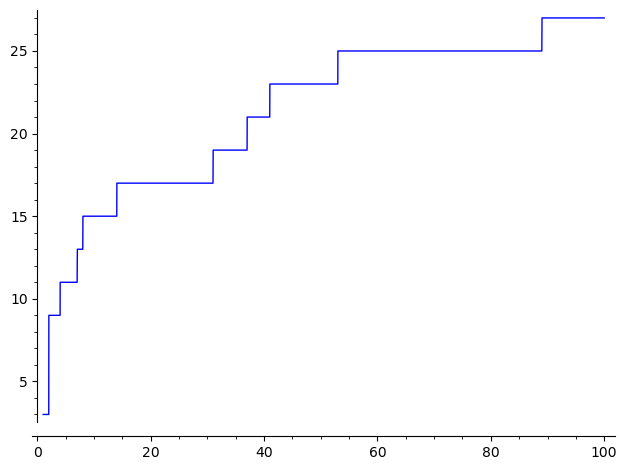

In [11]:
E = EllipticCurve([-4,1])
P, Q = E.gens()
pts = []
for n in srange(-50, 50):
    for m in srange(-50, 50):
        R = n*P+m*Q
        pts.append(R)

assert len(pts) == len(list(set(pts)))  # remove duplicates

pts.sort(key=lambda R : (naive_height(R), R[2]) )  # sort by naive height and by z- coordinates if equal

def nt(T):
    return len([R for R in pts if naive_height(R)<= T])
    
plot(nt,(1,100))

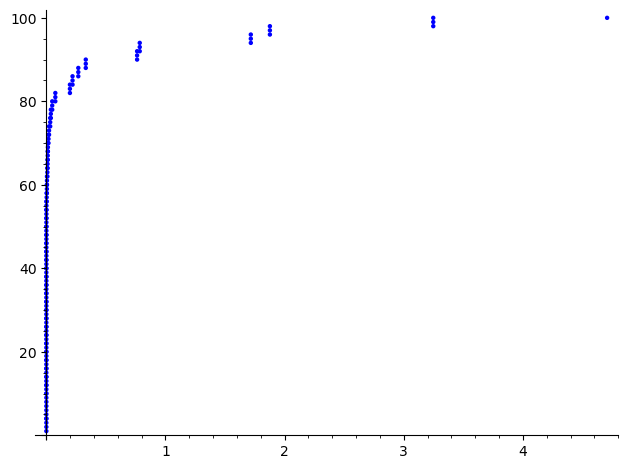

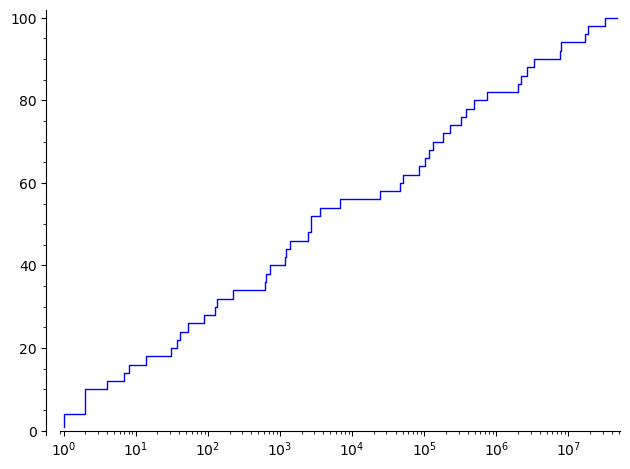

(None, None)

In [25]:
gra = []
i = 0
T = 1 
gr = Graphics()
for R in pts[:100]:
    i += 1
    hR = naive_height(R) 
    if hR > T:
        gra.append( (T,i) )
        gr += point( (T,i) )
        T = hR
    gra.append( (hR, i))
    gr += point( (hR, i ) )
    
show(gr), show(list_plot(gra, scale='semilogx', plotjoined=True))

In [26]:
import json
with open('nt_graph.json', 'w') as file:
    json.dump([[int(x),int(y)] for (x,y) in gra], file, indent=4)

In [22]:
for B in [-4..4]:
    E2 = EllipticCurve([-4, B])
    print(B, E2.torsion_points(), E2.rank())

-4 [(0 : 1 : 0)] 0
-3 [(0 : 1 : 0), (-1 : 0 : 1)] 0
-2 [(0 : 1 : 0)] 1
-1 [(0 : 1 : 0)] 0
0 [(0 : 1 : 0), (-2 : 0 : 1), (0 : 0 : 1), (2 : 0 : 1)] 0
1 [(0 : 1 : 0)] 2
2 [(0 : 1 : 0)] 0
3 [(0 : 1 : 0), (1 : 0 : 1)] 0
4 [(0 : 1 : 0)] 1


In [24]:
for A in [-4..4]:
    E2 = EllipticCurve([A, 1])
    print(A, E2.torsion_points(), E2.rank())

-4 [(0 : 1 : 0)] 2
-3 [(0 : 1 : 0)] 1
-2 [(0 : 1 : 0), (0 : -1 : 1), (0 : 1 : 1), (1 : 0 : 1)] 0
-1 [(0 : 1 : 0)] 1
0 [(0 : 1 : 0), (-1 : 0 : 1), (0 : -1 : 1), (0 : 1 : 1), (2 : -3 : 1), (2 : 3 : 1)] 0
1 [(0 : 1 : 0)] 1
2 [(0 : 1 : 0)] 1
3 [(0 : 1 : 0)] 1
4 [(0 : 1 : 0)] 1


## Points modulo Q

This is used in 3.2

In [13]:
E = EllipticCurve([-4,1])
E.Np(2), E.Np(5)

(3, 9)

In [14]:
def units(Q):
    return [ Mod(a,Q) for a in [1..Q] if gcd(a,Q) == 1]


def points_mod(Q):
    li = []
    ZQstar = units(Q)
    for Z in Q.divisors():
        for Y in Zmod(Q):
            for X in Zmod(Q):
                ZZ = Mod(Z,Q)
                if gcd([X,Y,Z]) == 1:
                    if Y^2*ZZ == X^3 - 4*X*ZZ^2 + ZZ^3:
                        if all((u*X, u*Y, u*ZZ) not in li for u in ZQstar):
                            li.append((X,Y,ZZ))
    return li

In [15]:
A = points_mod(10)
print(len(A), len([P for P in A if P[2]==1]))
A

27 16


[(0, 1, 1),
 (2, 1, 1),
 (8, 1, 1),
 (9, 2, 1),
 (4, 3, 1),
 (3, 4, 1),
 (5, 4, 1),
 (7, 4, 1),
 (3, 6, 1),
 (5, 6, 1),
 (7, 6, 1),
 (4, 7, 1),
 (9, 8, 1),
 (0, 9, 1),
 (2, 9, 1),
 (8, 9, 1),
 (8, 1, 2),
 (0, 3, 2),
 (4, 3, 2),
 (6, 3, 2),
 (0, 7, 2),
 (4, 7, 2),
 (6, 7, 2),
 (8, 9, 2),
 (0, 1, 5),
 (5, 2, 5),
 (0, 1, 0)]

In [18]:
li = []
for Q in [2..30]:
    li.append([Q,len(points_mod(Q))])
li

[[2, 3],
 [3, 7],
 [4, 8],
 [5, 9],
 [6, 21],
 [7, 12],
 [8, 24],
 [9, 21],
 [10, 27],
 [11, 15],
 [12, 56],
 [13, 18],
 [14, 36],
 [15, 63],
 [16, 48],
 [17, 25],
 [18, 63],
 [19, 25],
 [20, 72],
 [21, 84],
 [22, 45],
 [23, 30],
 [24, 168],
 [25, 45],
 [26, 54],
 [27, 63],
 [28, 96],
 [29, 22],
 [30, 189]]

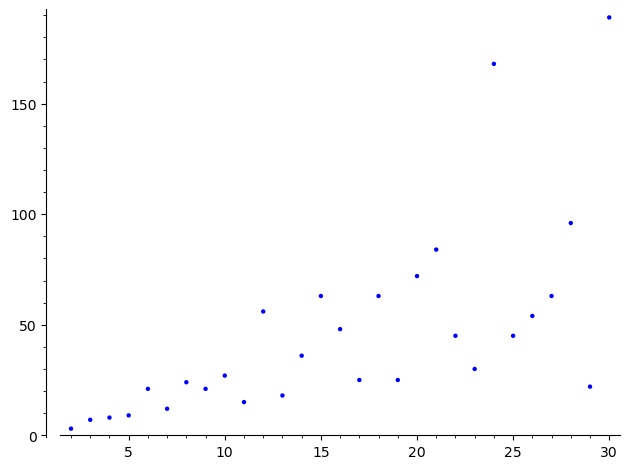

In [19]:
list_plot(li)

## Varying the curve

These are 

In [3]:
R.<X> = QQ[]
f = x^3 - 4*x + 1
[r[0].n() for r in f.roots()]

[0.254101688365052 + 2.22044604925031e-16*I,
 -2.11490754147676 - 5.55111512312578e-17*I,
 1.86080585311170 - 1.11022302462516e-16*I]

In [70]:
def u(t):
    return -2.11490754147676  + t*0.6
def v(t):
    return -2*sqrt(3.)/3 + .5*t
def A(t):
    return -3*v(t)^2
def B(t): 
    return -u(t)*(-3*v(t)^2+u(t)^2)
def EE(t):
    return EllipticCurve([A(t),B(t)])
    

In [71]:
gr = Graphics()
for k in [0..20]:
    t = k/20.
    gr += EE(t).plot(xmax=7,xmin=-7,ymax=4,ymin=-4,color=hue(t))

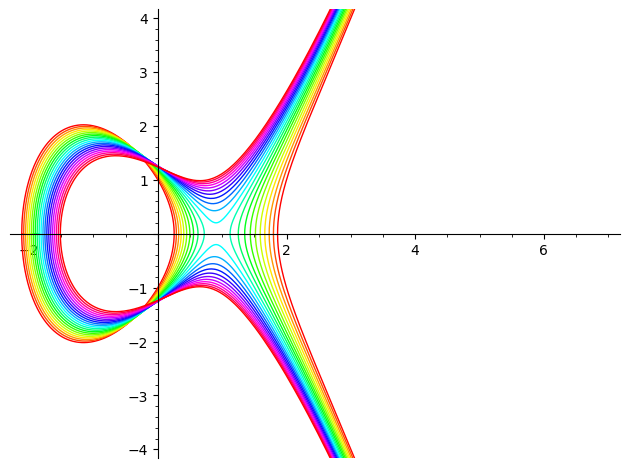

In [72]:
gr.show()

In [73]:
[(r[0].n(), r[1])for r in EE(x).discriminant().roots()]

[(2.76519288639704, 1),
 (0.486233838204355, 1),
 (9.60207003097510, 2),
 (2.97237098168728, 2)]

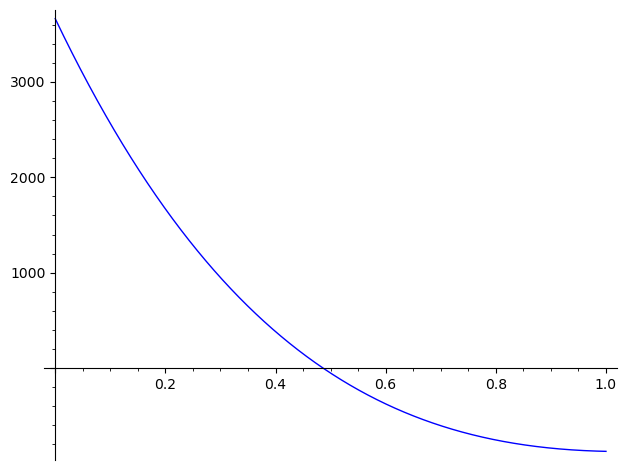

In [74]:
var("tt")
plot(EE(tt).discriminant(), (tt,0,1))

In [75]:
[(A(k/20),B(k/20)) for k in [0..20]]

[(-4.00000000000000, 1.00000000000004),
 (-3.82866991924311, 1.08033557600431),
 (-3.66108983848622, 1.15394394460660),
 (-3.49725975772934, 1.22100060580692),
 (-3.33717967697245, 1.28168105960526),
 (-3.18084959621556, 1.33616080600163),
 (-3.02826951545867, 1.38461534499601),
 (-2.87943943470179, 1.42722017658842),
 (-2.73435935394490, 1.46415080077886),
 (-2.59302927318801, 1.49558271756731),
 (-2.45544919243112, 1.52169142695379),
 (-2.32161911167423, 1.54265242893830),
 (-2.19153903091735, 1.55864122352083),
 (-2.06520895016046, 1.56983331070138),
 (-1.94262886940357, 1.57640419047995),
 (-1.82379878864668, 1.57852936285655),
 (-1.70871870788980, 1.57638432783117),
 (-1.59738862713291, 1.57014458540381),
 (-1.48980854637602, 1.55998563557448),
 (-1.38597846561913, 1.54608297834317),
 (-1.28589838486225, 1.52861211370989)]

In [76]:
E = EllipticCurve([-4,-2])
P, Q = E.gens()
P,Q

((-1 : 2 : 1), (0 : 1 : 1))